In [12]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
from scipy.io import loadmat

import sheet2
importlib.reload(sheet2)

from sheet2 import kmeans, em_gmm, plot_gmm_solution, agglo_dendro, kmeans_agglo

In [13]:
data = loadmat('problem_set2/data/usps.mat')

In [14]:
X = data["data_patterns"].T      # (2007, 256)
y = data["data_labels"].argmax(axis=0)   # (2007,)

X.shape, y.shape

((2007, 256), (2007,))

In [15]:
best_loss = np.inf

for run in range(10):
    centers_tmp, labels_tmp, loss_tmp = kmeans(X, k=10)

    if loss_tmp < best_loss:
        best_loss = loss_tmp
        best_centers = centers_tmp
        best_labels = labels_tmp

print("Best loss:", best_loss)

Iteration 1, number of changes: 2560, loss: 89858.7751214125
Iteration 2, number of changes: 2560, loss: 84478.20105726115
Iteration 3, number of changes: 2560, loss: 82763.1776481328
Iteration 4, number of changes: 2560, loss: 81827.77152898998
Iteration 5, number of changes: 2512, loss: 81342.8061303065
Iteration 6, number of changes: 2512, loss: 81092.49319877315
Iteration 7, number of changes: 2304, loss: 80961.9205821168
Iteration 8, number of changes: 2560, loss: 80854.15078809788
Iteration 9, number of changes: 2560, loss: 80745.92477446585
Iteration 10, number of changes: 2304, loss: 80627.13681882425
Iteration 11, number of changes: 2301, loss: 80415.98905934152
Iteration 12, number of changes: 2542, loss: 80194.15331289476
Iteration 13, number of changes: 2548, loss: 79990.35847180514
Iteration 14, number of changes: 2559, loss: 79781.4074899726
Iteration 15, number of changes: 2291, loss: 79657.53899526093
Iteration 16, number of changes: 2560, loss: 79600.22412240913
Iterat

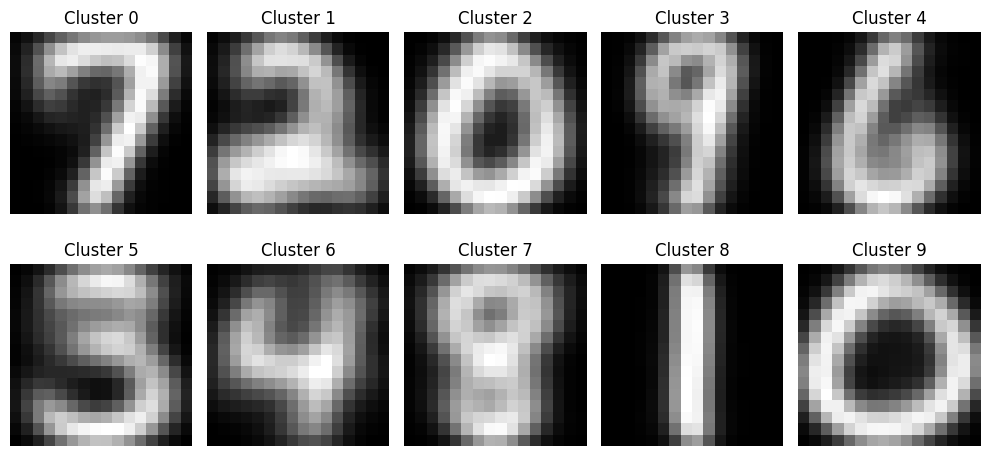

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(best_centers[i].reshape(16,16), cmap="gray")
    ax.set_title(f"Cluster {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
pi, mu, sigma, loglik = em_gmm(
    X,
    k=10,
    init_kmeans=True
)

print("Final log-likelihood:", loglik)

Iteration 1, number of changes: 2560, loss: 100958.85649749057
Iteration 2, number of changes: 2560, loss: 90770.88521359439
Iteration 3, number of changes: 2560, loss: 85500.57201672874
Iteration 4, number of changes: 2560, loss: 82588.74176766221
Iteration 5, number of changes: 2560, loss: 81341.99027545712
Iteration 6, number of changes: 2560, loss: 80924.16162804012
Iteration 7, number of changes: 2560, loss: 80562.20440668869
Iteration 8, number of changes: 2559, loss: 80301.97586485377
Iteration 9, number of changes: 2560, loss: 80011.25823451212
Iteration 10, number of changes: 2560, loss: 79742.92025188053
Iteration 11, number of changes: 2560, loss: 79461.73009505428
Iteration 12, number of changes: 2304, loss: 79132.06735369642
Iteration 13, number of changes: 2560, loss: 78891.26835379656
Iteration 14, number of changes: 2560, loss: 78751.06409337727
Iteration 15, number of changes: 2547, loss: 78695.7293757427
Iteration 16, number of changes: 2048, loss: 78637.4977041629
It

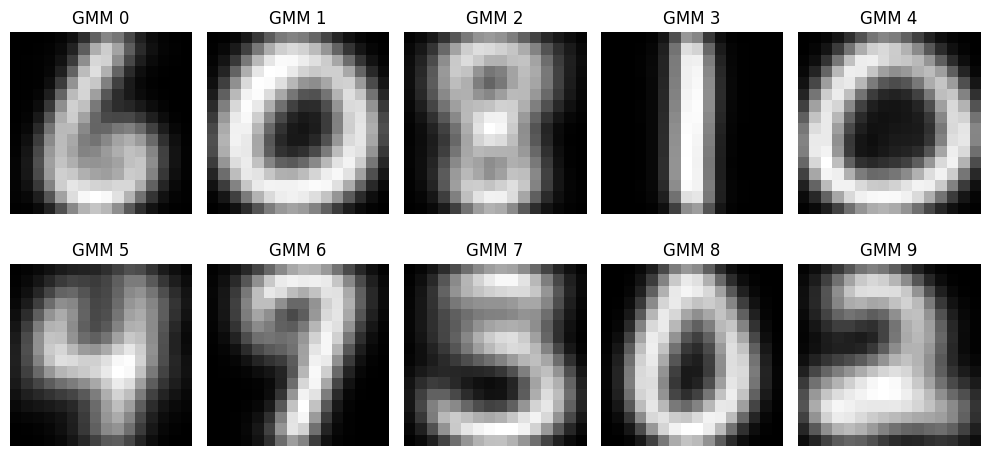

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(mu[i].reshape(16,16), cmap="gray")
    ax.set_title(f"GMM {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

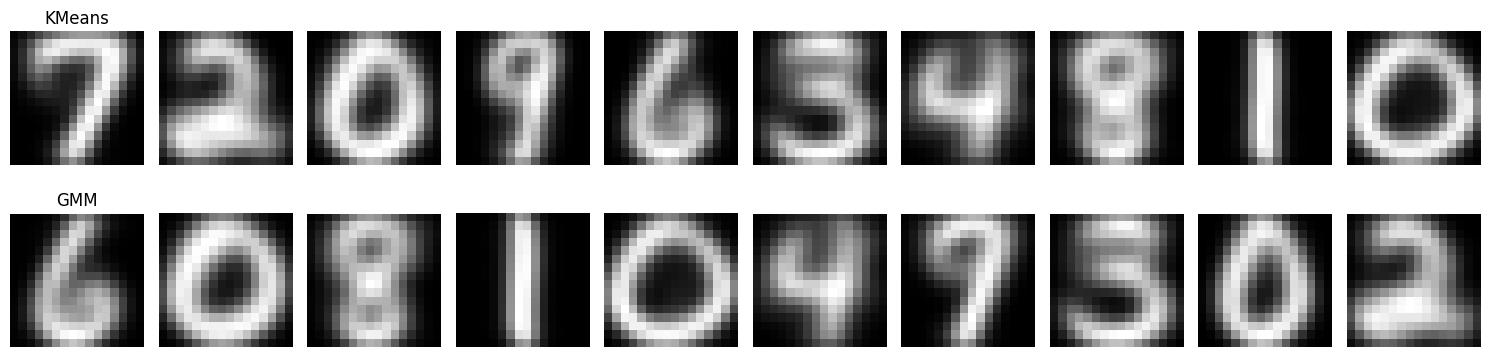

In [23]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axes[0, i].imshow(best_centers[i].reshape(16,16), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(mu[i].reshape(16,16), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("KMeans")
axes[1, 0].set_title("GMM")

plt.tight_layout()
plt.show()